In [ ]:
pip install git+https://github.com/openai/CLIP.git

In [26]:
%load_ext autoreload
%autoreload 2


In [27]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import random
import torch.nn.functional as F


random.seed(42)

from src.graphs import (
    normalize_embeddings,
    calculate_distance, 
    build_knn_graph, 
    symmetrize_matrix, 
    compute_normalized_laplacian, 
    laplacian_difference
    )

from src.utils import ( 
    topk_eigenpairs, 
    ky_fan_k_norm, 
    xpec_discrepancy, 
    extract_mismatched_clusters
    )

from src.visualize import (
    plot_eigen_spectrum, 
    visualize_mismatched_clusters
    )

from src.datasets import Multi30k




In [3]:
# !python extract_embeddings.py --dataset multi30k --model t5 --batch_size 2048 --normalize
# !python extract_embeddings.py --dataset multi30k --model roberta --batch_size 2048 --normalize

In [2]:
model_1 = 't5'
model_2 = 'roberta'

In [16]:
pip install natsort


Note: you may need to restart the kernel to use updated packages.


In [18]:
# !python src/extract_features.py --feat_extractor $model_1 --caption_file /Users/mghasemimada/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Desktop/Code/EXPECT/data/raw/multi30k/train.en
!python src/extract_features.py --feat_extractor $model_2 --caption_file /Users/mghasemimada/Library/CloudStorage/OneDrive-TheUniversityofMelbourne/Desktop/Code/EXPECT/data/raw/multi30k/train.en

Loading weights: 100%|█| 197/197 [00:00<00:00, 6303.37it/s, Materializing param=
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loaded 29000 texts.
Extracting text features: 100%|███████████████| 454/454 [07:29<00:00,  1.01it/s]
Saved features to ./roberta.npz


In [28]:
emb1 = torch.from_numpy(np.load(f"{model_1}.npz")["features"])
emb2 = torch.from_numpy(np.load(f"{model_2}.npz")["features"])

In [29]:
n_samples = 5000

emb1 = emb1[:n_samples]
emb2 = emb2[:n_samples]

In [30]:

def compute_laplacian(embeds, concept_vector=None):
    if concept_vector is not None:
        adj_matrix = concept_weighted_knn(embeds, concept_vector)
    else:
        adj_matrix = build_knn_graph(embeds, k=50, metric="cosine", return_weighted=False)

    adj_matrix = symmetrize_matrix(adj_matrix, mode="mean")
    L = compute_normalized_laplacian(adj_matrix)

    return L

In [33]:
L1 = compute_laplacian(emb1)
L2 = compute_laplacian(emb2)

DeltaL = laplacian_difference(L1, L2)
print(DeltaL.shape)

AssertionError: Torch not compiled with CUDA enabled

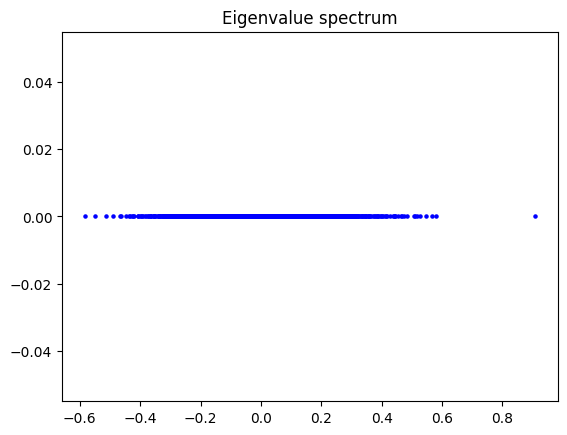

In [ ]:


def compute_eigens(matrix):
    n = matrix.shape[0]

    eigvals, eigvecs = torch.linalg.eigh(matrix)
    return eigvals, eigvecs
    
eigvals, eigvecs = compute_eigens(DeltaL)
plot_eigen_spectrum(eigvals)

In [12]:
import numpy as np
import umap
import matplotlib.pyplot as plt

def visualize(emb1, emb2, clusters):
    clustered_indices = []
    cluster_labels = []
    
    for cluster_id, cluster_indices in enumerate(clusters):
        if hasattr(cluster_indices, 'numpy'):
            indices = cluster_indices.cpu().numpy()
        else:
            indices = cluster_indices.cpu()
        
        clustered_indices.extend(indices)
        cluster_labels.extend([cluster_id] * len(indices))
    
    clustered_indices = np.array(clustered_indices)
    cluster_labels = np.array(cluster_labels)
    
    # Extract embeddings for both sets
    emb1_clustered = emb1[clustered_indices]
    emb2_clustered = emb2[clustered_indices]
    
    # UMAP
    reducer1 = umap.UMAP(n_components=2, random_state=42)
    embedding1_2d = reducer1.fit_transform(emb1_clustered)
    
    reducer2 = umap.UMAP(n_components=2, random_state=42)
    embedding2_2d = reducer2.fit_transform(emb2_clustered)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot emb1
    scatter1 = ax1.scatter(embedding1_2d[:, 0], embedding1_2d[:, 1], c=cluster_labels, cmap='tab10', s=50, alpha=0.6)
    ax1.set_title('UMAP visualization of emb1 (clustered embeddings)', fontsize=14)
    ax1.set_xlabel('UMAP 1')
    ax1.set_ylabel('UMAP 2')
    plt.colorbar(scatter1, ax=ax1, label='Cluster ID')
    
    # Plot emb2
    scatter2 = ax2.scatter(embedding2_2d[:, 0], embedding2_2d[:, 1], c=cluster_labels, cmap='tab10', s=50, alpha=0.6)
    ax2.set_title('UMAP visualization of emb2 (clustered embeddings)', fontsize=14)
    ax2.set_xlabel('UMAP 1')
    ax2.set_ylabel('UMAP 2')
    plt.colorbar(scatter2, ax=ax2, label='Cluster ID')
    
    plt.tight_layout()
    plt.show()


In [13]:
discrepancy = xpec_discrepancy(DeltaL, k=2, mode = "kyfan")
discrepancy

tensor(1.4938, device='cuda:0')

Found 5 mismatched clusters


/home/ssh_adnlp/miniconda3/envs/thinker/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ssh_adnlp/miniconda3/envs/thinker/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


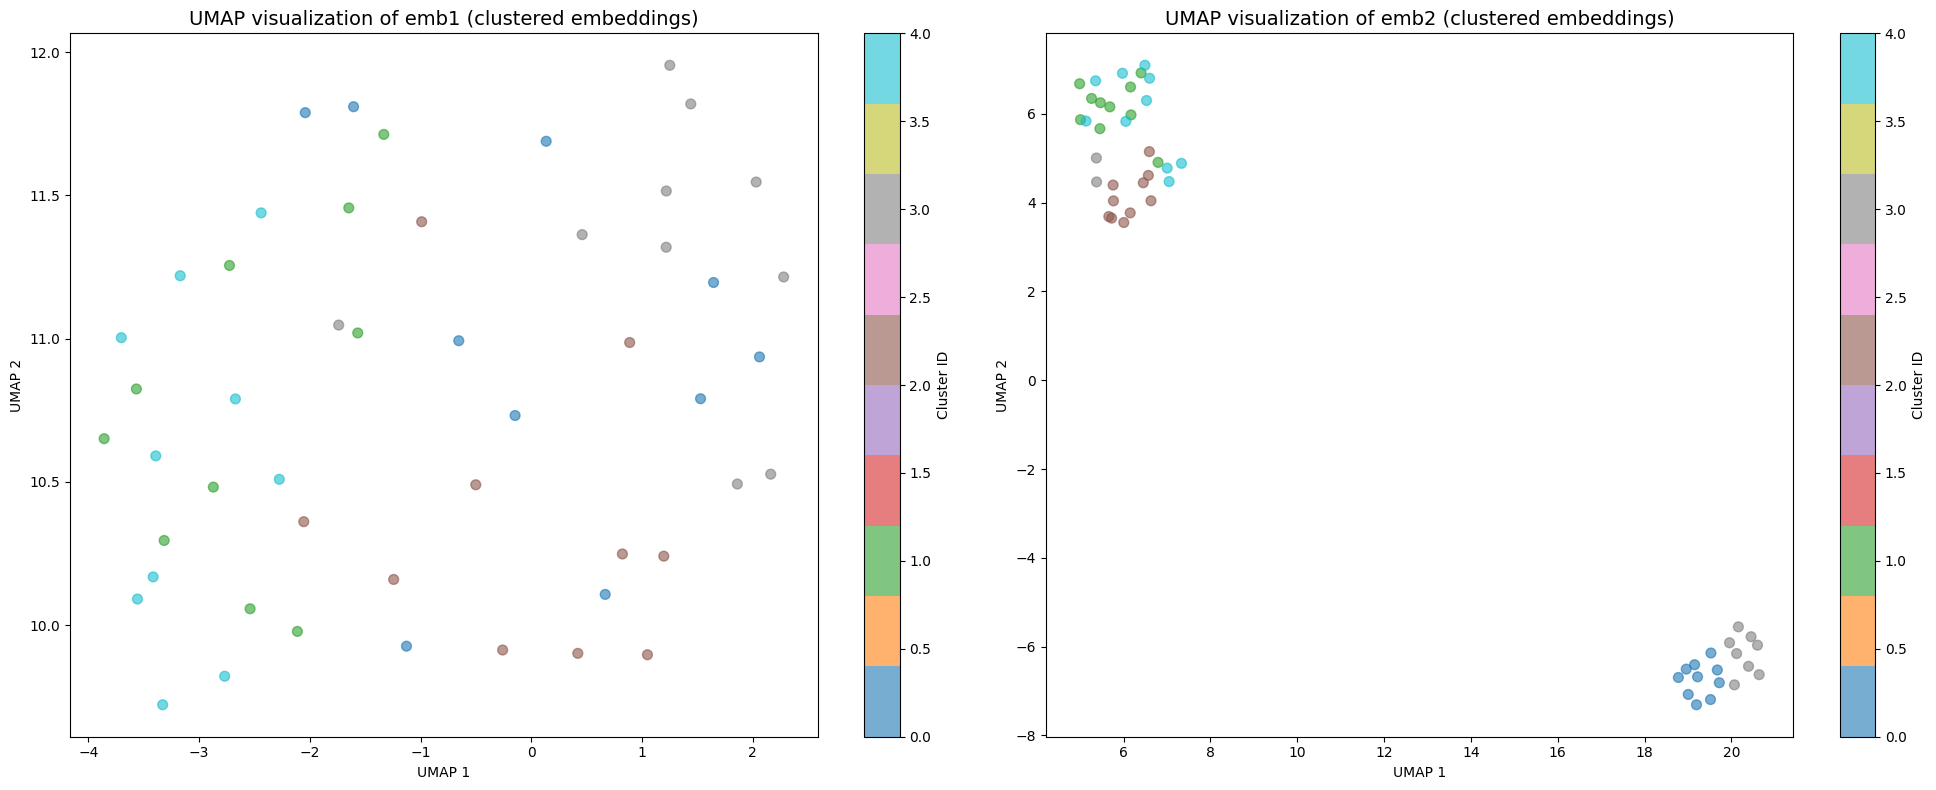

In [18]:
# Mismatched clusters
n_modes = 5
eigvals, eigvecs = topk_eigenpairs(DeltaL, k=n_modes)
# clusters = extract_mismatched_clusters(eigvecs, threshold=DeltaL)
clusters = extract_mismatched_clusters(eigvecs, top_n=10)
print(f"Found {len(clusters)} mismatched clusters")

visualize(emb1, emb2, clusters)

In [19]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from src.xpec.datasets.MultiLingualDatasets import Multi30k


# 2. Load Embeddings
embeds = emb1
indices = range(0,5000)

# *** FIX: Cast to float32 before converting to numpy ***
embeds_np = embeds.float().numpy()

# 3. Perform K-Means Clustering
n_clusters = n_modes
cluster_labels = clusters

# 4. t-SNE Visualization
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
# embeds_2d = tsne.fit_transform(embeds_np)

# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(embeds_2d[:, 0], embeds_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
# plt.colorbar(scatter, label='Cluster Label')
# plt.title(f't-SNE Visualization of {n_clusters} Clusters (BERT Embeddings)')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
# plt.show()

# 5. Display Text Samples for Each Cluster
print(f"{'='*20} Cluster Analysis {'='*20}")
dataset = Multi30k(split="train")
# df = pd.DataFrame({'Index': indices, 'Cluster': cluster_labels})

for c in range(n_clusters):
    print(f"\n🚀 Cluster {c}:")
    cluster_indices = cluster_labels[c]
    
    # Print up to 3 samples per cluster
    for i, idx in enumerate(cluster_indices):
        item = dataset[idx.item()]
        # Try to get English text, fallback to generic 'text' field
        text = item.get('text_en', item.get('text', '[No text found]'))
        print(f"  {i+1}. {text}")

==================== Cluster Analysis ====================
Loading compiled data for split: train

🚀 Cluster 0:
  1. A person swinging on a swing
  2. A dog shakes off water
  3. A brown dog sitting on grass
  4. Children fishing off a bridge
  5. A man playing a guitar with his band
  6. A man with two dogs on a beach
  7. Bearded man playing an acoustic guitar
  8. A young family sits on steps enjoying the day
  9. A man is smiling at a stuffed lion
  10. Two dogs playing with each other

🚀 Cluster 1:
  1. A man is playing a guitar.
  2. A man wearing a black jacket is playing guitar.
  3. A shirtless man wearing light blue shorts and a baseball cap stands at the front of a boat.
  4. A kid with Green shoes, red shorts, and a blue hat and shirt stands on a stretch of pavement.
  5. A man is laughing while wearing a white shirt.
  6. A man dressed in a burgundy shirt and black pants maneuvering a puppet which is holding a musical instrument.
  7. Lille boy standing behind a glass door

## Concept-Conditioned Analysis
### An edge is strong only if two nodes are close together and the neighbor is relevant to the target concept.

In [58]:
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from extract_embeddings import normalize_embeddings

import torch
from tqdm import tqdm

def concept_weighted_knn(embeddings, concept_embedding, k=5, metric="cosine"):
    # Normalize embeddings and concept
    embeddings = normalize_embeddings(embeddings, norm="l2") # (N, D)
    concept_embedding = normalize_embeddings(concept_embedding, norm="l2") # (1, D)
    
    embeddings = embeddings.to("cuda")
    concept_embedding = concept_embedding.to("cuda")

    num_samples = embeddings.shape[0]
    
    # Compute similarity score for every node relative to the concept
    # cosine similarity --> dot product of normalized vectors
    node_relevance = torch.matmul(embeddings, concept_embedding.T).squeeze() # (num_samples, 1)
    # node_relevance = torch.clamp(node_relevance, min=0)

    coo_rows = []
    coo_cols = []
    coo_values = []
    
    chunk_threshold = 10000 if num_samples > 100000 else 1000
    
    for row_start in tqdm(range(0, num_samples, chunk_threshold)):
        row_end = min(row_start + chunk_threshold, num_samples)
        emb_chunk = embeddings[row_start:row_end]

        # Calculate kernel matrix
        dist_matrix = calculate_distance(emb_chunk, embeddings, metric=metric)
        dist_matrix.fill_diagonal_(torch.max(dist_matrix)) 

        # Get top k neighbors based on distance
        values, indices = torch.topk(dist_matrix, k=k, dim=-1, largest=False)
        
        # 3. Apply the concept weighting
        for i in range(emb_chunk.shape[0]):
            global_row_idx = row_start + i
            neighbor_indices = indices[i]
            
            # Concept-based weight --> Multiply the edge by the relevance of the neighbor node
            # This ensures edges only stay "strong" if the neighbor aligns with the concept
            concept_weights = node_relevance[neighbor_indices]
            
            # Final Edge Weight = Base Similarity * Concept Relevance
            final_weights = values[i] * concept_weights

            coo_rows.extend([global_row_idx] * k)
            coo_cols.extend(neighbor_indices.cpu().tolist())
            coo_values.extend(final_weights.cpu().tolist())

    # Return as weighted sparse matrix
    adj_matrix = torch.sparse_coo_tensor(
        torch.tensor([coo_rows, coo_cols]), 
        torch.tensor(coo_values), 
        [num_samples, num_samples]
    )

    return adj_matrix

In [69]:
with open('concept.txt', 'w') as f: 
    f.write('Body Posture and Positioning')

In [70]:
!python embedding-comparison/spec/extract_features.py --feat_extractor $model_1 --caption_file /home/ssh_adnlp/reza/XPEC/concept.txt --output f"{model_1}_concept.npz"
!python embedding-comparison/spec/extract_features.py --feat_extractor $model_2 --caption_file /home/ssh_adnlp/reza/XPEC/concept.txt --output f"{model_2}_concept.npz"

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565
Loaded 1 texts.
Extracting text features: 100%|███████████████████| 1/1 [00:00<00:00,  2.63it/s]
Saved features to ft5_concept.npz
Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Loaded 1 texts.
Extracting text features: 100%|███████████████████| 1/1 [00:00<00:00,  3.40it/s]
Saved features to froberta_concept.

In [71]:
concept_emb1 = torch.from_numpy(np.load(f"f{model_1}_concept.npz")['features'])
concept_emb2 = torch.from_numpy(np.load(f"f{model_2}_concept.npz")['features'])

L1 = compute_laplacian(emb1, concept_vector=concept_emb1)
L2 = compute_laplacian(emb2, concept_vector=concept_emb2)

DeltaL = laplacian_difference(L1, L2)
print(DeltaL.shape)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 23.73it/s]

torch.Size([5000, 5000])


Found 2 mismatched clusters


/home/ssh_adnlp/miniconda3/envs/thinker/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/ssh_adnlp/miniconda3/envs/thinker/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


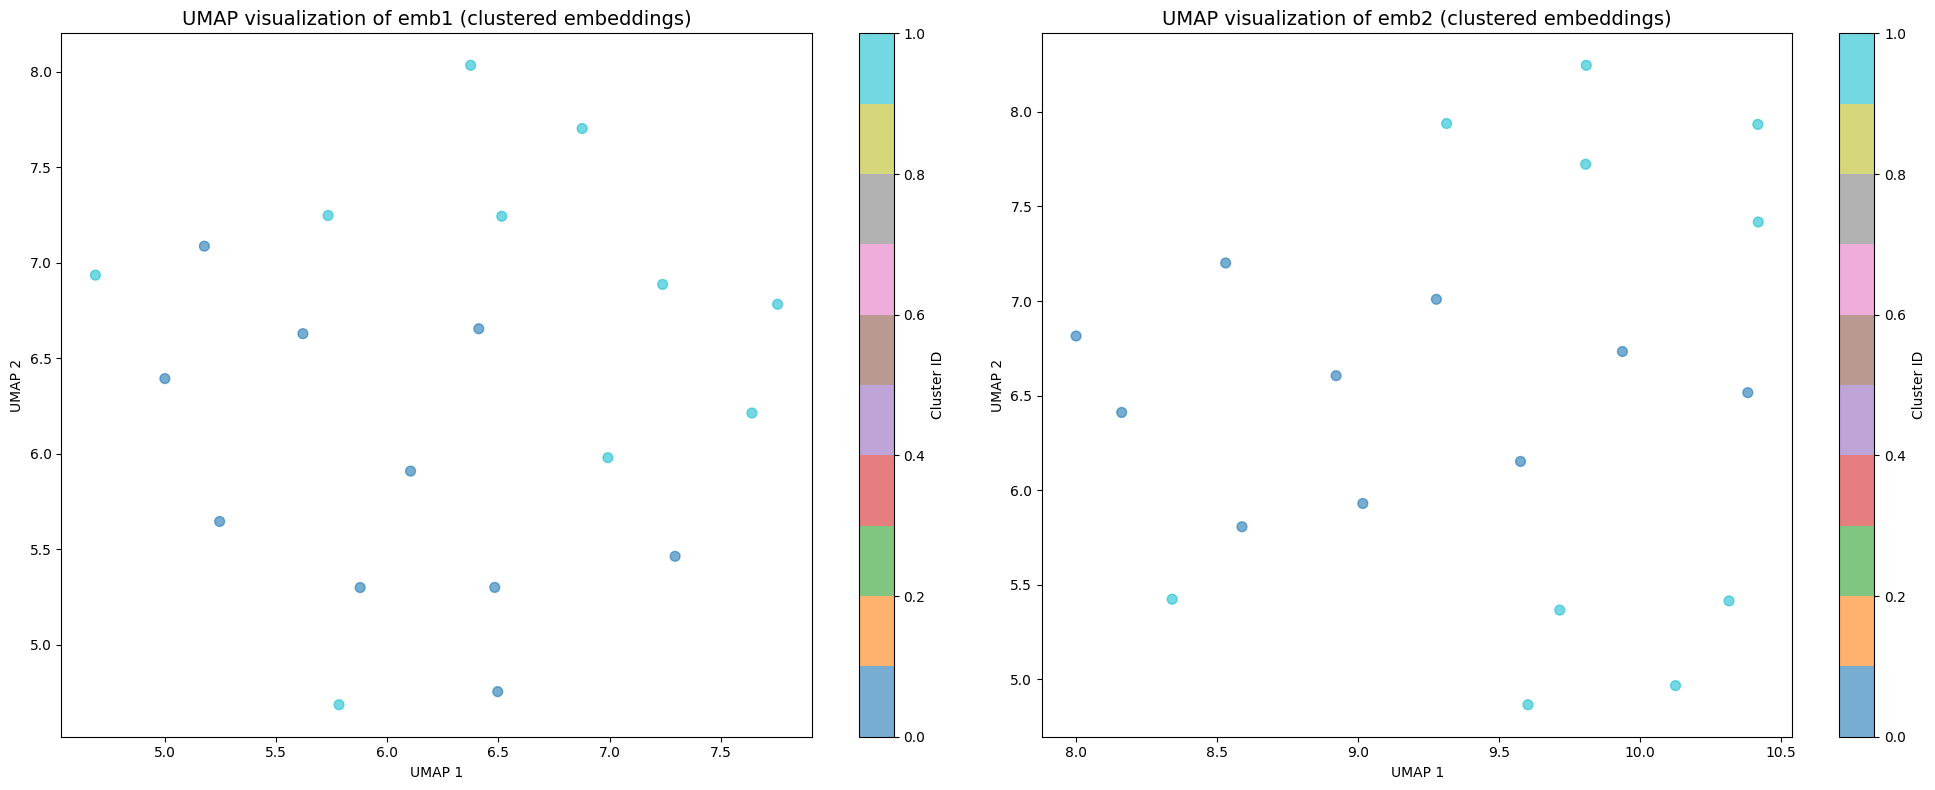

In [72]:
# Mismatched clusters
n_modes = 2
eigvals, eigvecs = topk_eigenpairs(DeltaL, k=n_modes)
# clusters = extract_mismatched_clusters(eigvecs, threshold=DeltaL)
clusters = extract_mismatched_clusters(eigvecs, top_n=10)
print(f"Found {len(clusters)} mismatched clusters")

visualize(emb1, emb2, clusters)

In [73]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
from src.xpec.datasets.MultiLingualDatasets import Multi30k



# 2. Load Embeddings
embeds = emb1
indices = range(0,5000)

# *** FIX: Cast to float32 before converting to numpy ***
embeds_np = embeds.float().numpy()

# 3. Perform K-Means Clustering
n_clusters = n_modes
cluster_labels = clusters

# 4. t-SNE Visualization
# tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')
# embeds_2d = tsne.fit_transform(embeds_np)

# plt.figure(figsize=(12, 8))
# scatter = plt.scatter(embeds_2d[:, 0], embeds_2d[:, 1], c=cluster_labels, cmap='tab10', alpha=0.7)
# plt.colorbar(scatter, label='Cluster Label')
# plt.title(f't-SNE Visualization of {n_clusters} Clusters (BERT Embeddings)')
# plt.xlabel('t-SNE Dimension 1')
# plt.ylabel('t-SNE Dimension 2')
# plt.show()

# 5. Display Text Samples for Each Cluster
print(f"{'='*20} Cluster Analysis {'='*20}")
dataset = Multi30k(split="train")
# df = pd.DataFrame({'Index': indices, 'Cluster': cluster_labels})

for c in range(n_clusters):
    print(f"\n🔴 Cluster {c}:")
    cluster_indices = cluster_labels[c]
    
    # Print up to 3 samples per cluster
    for i, idx in enumerate(cluster_indices):
        item = dataset[idx.item()]
        # Try to get English text, fallback to generic 'text' field
        text = item.get('text_en', item.get('text', '[No text found]'))
        print(f"  {i+1}. {text}")

==================== Cluster Analysis ====================
Loading compiled data for split: train

🔴 Cluster 0:
  1. Man looking into the camera playing a guitar
  2. Children fishing off a bridge
  3. Two teams battle it out for the win!
  4. Indian ladies dancing in front of crowd
  5. Bearded man playing an acoustic guitar
  6. A man cooking with fire in like 5 pots at the same time!
  7. Crowd gathers to listen to a band
  8. A man playing a guitar with his band
  9. A person swinging on a swing
  10. The music concert is just started at the Giant stadium

🔴 Cluster 1:
  1. Workers are serving up customers lined up in front of a Martins famous louisiana sausages vendor tent
  2. Chefs on a balcony take a break from work
  3. Five workers sitting in front of trucks eating lunch
  4. A man in a gray shirt and a hat holding a jackhammer
  5. S large man in a blue shirt and shorts leaning against a van in front of a store called "Terrible's"
  6. A man wearing brown is outside next to 